# Predictive Maintenance MLOps Pipeline

**Domain:** Industrial IoT / Manufacturing  
**Task:** Multi-class machine failure prediction  
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

## Business Context

A heavy-equipment manufacturer runs thousands of machines on the shop floor. Each machine streams sensor readings that can be used to identify potential failure modes before downtime occurs.

This notebook builds an end-to-end MLOps workflow that validates incoming sensor data, trains and tracks multiple classifiers, tunes and registers the best model, monitors data drift, and explains model behavior using class-specific SHAP analysis.

## Failure Classes

| Code | Name | Description |
|---:|---|---|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

## 1. Data Loading, Schema Validation and EDA

### 1.1 Load the datasets

Load the historical training data, the stable current production batch, and the heavy-load stress batch. Then inspect shapes and a sample of the training data.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train   = pd.read_csv('data/train.csv')
current = pd.read_csv('data/current.csv')
stress  = pd.read_csv('data/stress.csv')

print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

train.head()

train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### 1.2 Pandera schema validation

Define a schema for the raw sensor columns and validate all three datasets before modeling. The stress batch is validated lazily so all violations can be reviewed together.

In [2]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

schema = DataFrameSchema({
    "Type": Column(
        str,
        Check.isin(["L", "M", "H"]),
        nullable=False
    ),

    "Air temperature": Column(
        float,
        Check.in_range(295.0, 305.0),
        nullable=False
    ),

    "Process temperature": Column(
        float,
        Check.in_range(305.0, 315.0),
        nullable=False
    ),

    "Rotational speed": Column(
        "int64",
        Check.in_range(1000, 2900),
        nullable=False
    ),

    "Torque": Column(
        float,
        Check.in_range(3.0, 80.0),
        nullable=False
    ),

    "Tool wear": Column(
        "int64",
        Check.in_range(0, 253),
        nullable=False
    ),

    "Failure_Type": Column(
        "int64",
        Check.isin([0, 1, 2, 3, 4]),
        nullable=False
    )
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

schema.validate(train)
schema.validate(current)

print("train and current validation passed.")

try:
    schema.validate(stress, lazy=True)
    print("stress validation passed.")
except pa.errors.SchemaErrors as err:
    print("stress validation failed. Violation summary:")
    display(err.failure_cases)

train and current validation passed.
stress validation passed.


### 1.3 Exploratory data analysis

Inspect the target class distribution, key sensor distributions, and machine type distribution to understand imbalance and feature behavior.

Class distribution of Failure_Type:
              count  percentage
Failure_Type                   
0              6762       96.70
1                30        0.43
2                76        1.09
3                56        0.80
4                69        0.99

The dataset is not balanced. One class dominates the data.


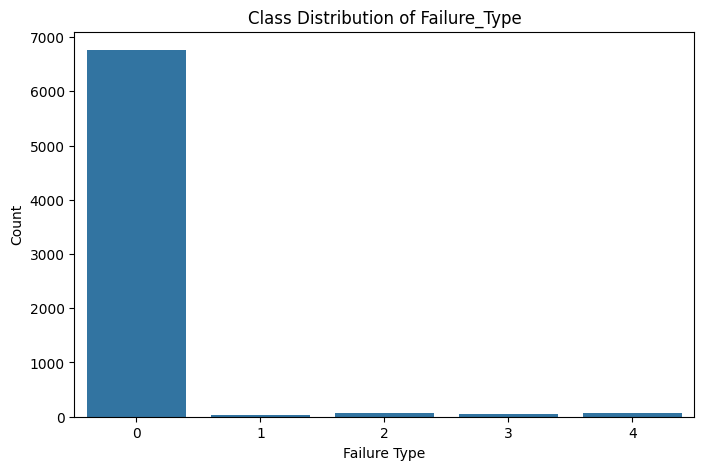

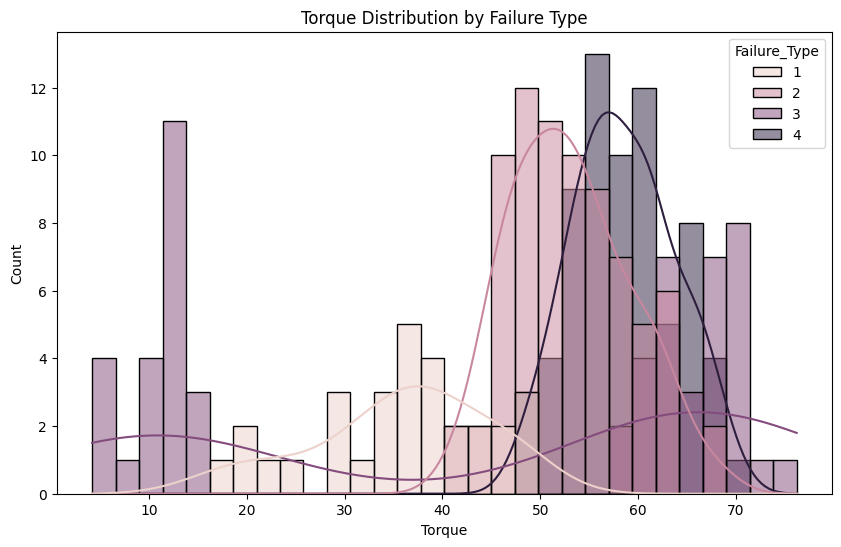

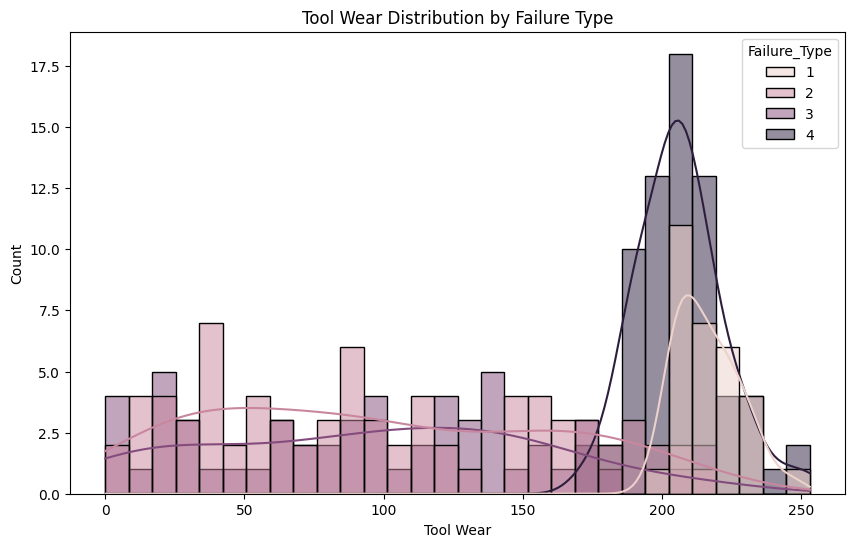


Type distribution:
      count  percentage
Type                   
H       706       10.10
L      4213       60.25
M      2074       29.66


In [3]:
print("Class distribution of Failure_Type:")
class_counts = train["Failure_Type"].value_counts().sort_index()
class_percentages = train["Failure_Type"].value_counts(normalize=True).sort_index() * 100

class_distribution = (
    class_counts
    .to_frame(name="count")
    .assign(percentage=class_percentages.round(2))
)

print(class_distribution)

# Check balance
majority_pct = class_percentages.max()

if majority_pct > 70:
    print("\nThe dataset is not balanced. One class dominates the data.")
else:
    print("\nThe dataset looks reasonably balanced.")

# Bar chart
plt.figure(figsize=(8, 5))
sns.countplot(data=train, x="Failure_Type", order=sorted(train["Failure_Type"].unique()))
plt.title("Class Distribution of Failure_Type")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.show()


failures_only = train[train["Failure_Type"] != 0].copy()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=failures_only,
    x="Torque",
    hue="Failure_Type",
    kde=True,
    bins=30,
    multiple="layer"
)
plt.title("Torque Distribution by Failure Type")
plt.xlabel("Torque")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(10, 6))
sns.histplot(
    data=failures_only,
    x="Tool wear",
    hue="Failure_Type",
    kde=True,
    bins=30,
    multiple="layer"
)
plt.title("Tool Wear Distribution by Failure Type")
plt.xlabel("Tool Wear")
plt.ylabel("Count")
plt.show()


print("\nType distribution:")
type_counts = train["Type"].value_counts().sort_index()
type_percentages = train["Type"].value_counts(normalize=True).sort_index() * 100

type_distribution = (
    type_counts
    .to_frame(name="count")
    .assign(percentage=type_percentages.round(2))
)

print(type_distribution)

### 1.4 Feature engineering

Create physically meaningful derived features for all datasets. `Power_W` captures mechanical power demand, while `Temp_diff` captures the thermal gap between process and air temperature.

In [4]:
def engineer_features(df):
    df = df.copy()
    df["Power_W"] = df["Torque"] * (df["Rotational speed"] * 2 * np.pi / 60)

    df["Temp_diff"] = df["Process temperature"] - df["Air temperature"]

    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

datasets = {
    "train": train,
    "current": current,
    "stress": stress
}

for name, df in datasets.items():
    print(f"\nMean derived features by Failure_Type - {name}:")
    print(
        df
        .groupby("Failure_Type")[["Power_W", "Temp_diff"]]
        .mean()
        .round(2)
    )


Mean derived features by Failure_Type - train:
              Power_W  Temp_diff
Failure_Type                    
0             6248.24      10.01
1             5763.09       9.97
2             7403.55       8.23
3             6664.38       9.82
4             8216.07      10.07

Mean derived features by Failure_Type - current:
              Power_W  Temp_diff
Failure_Type                    
0             6253.90      10.10
1             6263.90       9.47
2             7112.86       8.31
3             7633.43      10.28
4             8401.13      10.01

Mean derived features by Failure_Type - stress:
              Power_W  Temp_diff
Failure_Type                    
0             6762.74       9.97
1             6213.17       9.67
2             8042.59       8.21
3             7570.23      10.13
4             8176.59       9.99


## 2. Experiment Tracking and Model Selection

### 2.1 Feature setup, stratified split and SMOTE

Encode the `Type` column, create the model feature matrix, perform a stratified train-validation split, and apply SMOTE only to the training split.

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

X = train[FEATURES]
y = train["Failure_Type"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(k_neighbors=3, random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Post-SMOTE class distribution:")
print(y_train_smote.value_counts().sort_index())

print("\nPost-SMOTE class distribution percentage:")
print((y_train_smote.value_counts(normalize=True).sort_index() * 100).round(2))

Post-SMOTE class distribution:
Failure_Type
0    5409
1    5409
2    5409
3    5409
4    5409
Name: count, dtype: int64

Post-SMOTE class distribution percentage:
Failure_Type
0    20.0
1    20.0
2    20.0
3    20.0
4    20.0
Name: proportion, dtype: float64


SMOTE is applied only to the training split to avoid data leakage. The validation set should represent real unseen data, so artificially generating samples in it would make evaluation overly optimistic and less reliable.

### 2.2 Model training and MLflow tracking

Train Logistic Regression, Random Forest, XGBoost, and LightGBM. Track parameters, model artifacts, overall metrics, and per-class F1 scores in MLflow. Select the best baseline model using `macro_f1`.

In [6]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])
for model_name, model in models_to_run.items():

    with mlflow.start_run(run_name=model_name):

        # Fit model on SMOTE-resampled training data
        model.fit(X_train_smote, y_train_smote)

        # Predict on untouched validation set
        y_pred = model.predict(X_val)

        # Overall metrics
        macro_f1 = f1_score(y_val, y_pred, average="macro")
        weighted_f1 = f1_score(y_val, y_pred, average="weighted")
        accuracy = accuracy_score(y_val, y_pred)

        # Per-class F1
        per_class_f1 = f1_score(
            y_val,
            y_pred,
            labels=CLASS_LIST,
            average=None
        )

        # Log model name as parameter
        mlflow.log_param("model", model_name)

        # Log common metrics
        mlflow.log_metric("macro_f1", macro_f1)
        mlflow.log_metric("weighted_f1", weighted_f1)
        mlflow.log_metric("accuracy", accuracy)

        # Log per-class F1 metrics
        for class_label, class_f1 in zip(CLASS_LIST, per_class_f1):
            mlflow.log_metric(f"f1_class_{class_label}", class_f1)

        # Log model artifact
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            input_example=X_val.iloc[:5]
        )

        # Store results for comparison table
        results[model_name] = {
            "model": model_name,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "accuracy": accuracy,
            "f1_class_0": per_class_f1[0],
            "f1_class_1": per_class_f1[1],
            "f1_class_2": per_class_f1[2],
            "f1_class_3": per_class_f1[3],
            "f1_class_4": per_class_f1[4]
        }

comparison_df = pd.DataFrame(results).T.reset_index(drop=True)

comparison_df = comparison_df.sort_values(
    by="macro_f1",
    ascending=False
)

print("Model comparison table:")
display(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]["model"]
best_macro_f1 = comparison_df.iloc[0]["macro_f1"]

print(f"Best model by macro F1: {best_model_name}")
print(f"Best macro F1: {best_macro_f1:.4f}")

2026/05/11 15:05:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/11 15:05:13 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

Model comparison table:


,model,macro_f1,weighted_f1,accuracy,f1_class_0,f1_class_1,f1_class_2,f1_class_3,f1_class_4
2,XGBoost,0.748062,0.985147,0.984274,0.992231,0.133333,0.965517,0.88,0.769231
1,RandomForest,0.735542,0.985459,0.984989,0.992614,0.0,0.928571,0.956522,0.8
3,LightGBM,0.729645,0.985088,0.984274,0.992231,0.0,0.965517,0.833333,0.857143
0,LogisticRegression,0.531231,0.932771,0.904217,0.94835,0.144928,0.454545,0.458333,0.65


Best model by macro F1: XGBoost
Best macro F1: 0.7481


### 2.3 Optuna tuning and MLflow Model Registry

Tune the strongest baseline model using Optuna, optimize for validation `macro_f1`, register the tuned model in MLflow, and assign the `production` alias.

In [7]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    model = XGBClassifier(**params)

    # Train on SMOTE training data
    model.fit(X_train_smote, y_train_smote)

    # Validate on untouched validation set
    y_pred = model.predict(X_val)

    macro_f1 = f1_score(
        y_val,
        y_pred,
        average="macro"
    )

    return macro_f1

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

print("Best Optuna macro F1:", round(study.best_value, 4))
print("Best hyperparameters:")
print(study.best_params)

best_params = study.best_params.copy()

best_params.update({
    "random_state": 42,
    "eval_metric": "mlogloss",
    "verbosity": 0
})

best_xgb_model = XGBClassifier(**best_params)

best_xgb_model.fit(X_train_smote, y_train_smote)

y_pred_best = best_xgb_model.predict(X_val)

best_macro_f1 = f1_score(y_val, y_pred_best, average="macro")
best_weighted_f1 = f1_score(y_val, y_pred_best, average="weighted")

per_class_f1 = f1_score(
    y_val,
    y_pred_best,
    labels=CLASS_LIST,
    average=None
)

from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature

registered_model_name = "PredMaint_XGBoost"

with mlflow.start_run(run_name="Optuna_Best_XGBoost") as run:

    # Log best hyperparameters
    mlflow.log_params(best_params)

    # Log metrics
    mlflow.log_metric("macro_f1", best_macro_f1)
    mlflow.log_metric("weighted_f1", best_weighted_f1)

    for class_label, class_f1 in zip(CLASS_LIST, per_class_f1):
        mlflow.log_metric(f"f1_class_{class_label}", class_f1)

    # Model signature
    signature = infer_signature(X_val, y_pred_best)

    # Log and register model
    model_info = mlflow.sklearn.log_model(
        sk_model=best_xgb_model,
        artifact_path="model",
        signature=signature,
        input_example=X_val.iloc[:5],
        registered_model_name=registered_model_name
    )

    run_id = run.info.run_id

# Promote registered model to production alias
client = MlflowClient()

latest_versions = client.search_model_versions(
    f"name = '{registered_model_name}'"
)

latest_version = max(
    latest_versions,
    key=lambda version: int(version.version)
)

client.set_registered_model_alias(
    name=registered_model_name,
    alias="production",
    version=latest_version.version
)

# Baseline XGBoost macro F1 from previous model-selection results
baseline_xgb_macro_f1 = comparison_df.loc[
    comparison_df["model"] == "XGBoost",
    "macro_f1"
].values[0]

# Improvement over baseline XGBoost
improvement = best_macro_f1 - baseline_xgb_macro_f1

print("\nFinal tuned XGBoost results:")
print(f"Baseline XGBoost macro F1: {baseline_xgb_macro_f1:.4f}")
print(f"Tuned XGBoost macro F1: {best_macro_f1:.4f}")
print(f"Improvement in macro F1: {improvement:.4f}")

print(f"\nRegistered model name: {registered_model_name}")
print(f"Promoted version: {latest_version.version}")
print("Alias: production")
print("Saved local model: best_predmaint_xgboost.joblib")

joblib.dump(best_xgb_model, "best_predmaint_xgboost.joblib")

2026/05/11 15:25:23 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_Optuna' does not exist. Creating a new experiment.


Best Optuna macro F1: 0.761
Best hyperparameters:
{'n_estimators': 462, 'max_depth': 4, 'learning_rate': 0.08853874505145662, 'min_child_weight': 6.83456102352091, 'subsample': 0.6473544266888274, 'colsample_bytree': 0.8745534255937363, 'gamma': 0.47778375377411253, 'reg_alpha': 1.9045113036901531e-07, 'reg_lambda': 0.0007066255503193089}


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.



Final tuned XGBoost results:
Baseline XGBoost macro F1: 0.7481
Tuned XGBoost macro F1: 0.7610
Improvement in macro F1: 0.0129

Registered model name: PredMaint_XGBoost
Promoted version: 1
Alias: production
Saved local model: best_predmaint_xgboost.joblib


['best_predmaint_xgboost.joblib']

In [14]:
joblib.dump(best_xgb_model, "best_model.pkl")

['best_model.pkl']

In [15]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

## 3. Drift Detection and Monitoring

This stage compares incoming batches against the historical training baseline to identify whether production data remains in-distribution.

### 3.1 Current batch drift report

Use the training data as the reference baseline and compare it with the current stable production batch. Save the Evidently report as `drift_current.html`.

In [9]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

reference_data = train[FEAT_COLS].copy()
current_data = current[FEAT_COLS].copy()

drift_report = Report(metrics=[
    DataDriftPreset()
])

drift_report.run(
    reference_data=reference_data,
    current_data=current_data
)

drift_report.save_html("drift_current.html")

drift_results = drift_report.as_dict()

dataset_drift = None
number_of_drifted_features = None
share_of_drifted_features = None
drift_by_feature = None

for metric in drift_results["metrics"]:
    result = metric.get("result", {})

    if "dataset_drift" in result:
        dataset_drift = result.get("dataset_drift")

    if "number_of_drifted_columns" in result:
        number_of_drifted_features = result.get("number_of_drifted_columns")

    if "share_of_drifted_columns" in result:
        share_of_drifted_features = result.get("share_of_drifted_columns")

    if "drift_by_columns" in result:
        drift_by_feature = result.get("drift_by_columns")

print("Drift report saved as drift_current.html")
print("Data drift detected:", dataset_drift)
print("Number of drifted features:", number_of_drifted_features)
print("Share of drifted features:", share_of_drifted_features)

if drift_by_feature is not None:
    print("\nFeature-level drift summary:")

    for feature, details in drift_by_feature.items():
        print(
            f"{feature}: drift_detected={details.get('drift_detected')}, "
            f"p_value={details.get('p_value')}, "
            f"stat_test={details.get('stattest_name')}"
        )
else:
    print("\nFeature-level drift details were not found in this Evidently result structure.")

Drift report saved as drift_current.html
Data drift detected: False
Number of drifted features: 0
Share of drifted features: 0.0

Feature-level drift summary:
Air temperature: drift_detected=False, p_value=None, stat_test=Wasserstein distance (normed)
Process temperature: drift_detected=False, p_value=None, stat_test=Wasserstein distance (normed)
Rotational speed: drift_detected=False, p_value=None, stat_test=Wasserstein distance (normed)
Tool wear: drift_detected=False, p_value=None, stat_test=Wasserstein distance (normed)
Torque: drift_detected=False, p_value=None, stat_test=Wasserstein distance (normed)


### 3.2 Stress batch drift report

Repeat the drift analysis for the heavy-load stress batch. Use per-column drift metrics to identify which operational features shifted and by how much.

In [ ]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

stress_data = stress[FEAT_COLS].copy()

stress_drift_report = Report(metrics=[
    DatasetDriftMetric(),
    *[
        ColumnDriftMetric(
            column_name=col,
            stattest="wasserstein"
        )
        for col in FEAT_COLS
    ]
])

stress_drift_report.run(
    reference_data=reference_data,
    current_data=stress_data
)

stress_drift_report.save_html("drift_stress.html")

stress_drift_results = stress_drift_report.as_dict()

rows = []

for metric in stress_drift_results["metrics"]:
    result = metric.get("result", {})

    if "column_name" in result:
        feature = result.get("column_name")

        ref_mean = reference_data[feature].mean()
        current_mean = stress_data[feature].mean()
        delta = current_mean - ref_mean

        rows.append({
            "feature": feature,
            "drift_detected": result.get("drift_detected"),
            "wasserstein_score": result.get("drift_score"),
            "ref_mean": ref_mean,
            "current_mean": current_mean,
            "delta": delta
        })

stress_drift_table = pd.DataFrame(rows)

stress_drift_table = stress_drift_table[
    [
        "feature",
        "drift_detected",
        "wasserstein_score",
        "ref_mean",
        "current_mean",
        "delta"
    ]
]

print("Stress drift report saved as drift_stress.html")
print("\nPer-feature drift table:")
display(stress_drift_table.round(4))

Stress drift report saved as drift_stress.html

Per-feature drift table:


,feature,drift_detected,wasserstein_score,ref_mean,current_mean,delta
0,Air temperature,False,0.0344,300.0116,300.0538,0.0422
1,Process temperature,False,0.0377,310.0049,310.0086,0.0037
2,Rotational speed,True,0.2354,1539.0176,1497.0747,-41.9429
3,Torque,True,0.4739,39.9958,44.7241,4.7283
4,Tool wear,True,0.6455,107.6791,148.8699,41.1908


### 3.3 Retraining decision

Connect the drifted features with class-specific SHAP drivers to decide whether the model needs retraining or closer production monitoring.

1. Features that drifted: The stress batch shows drift in `Rotational speed`, `Torque`, and `Tool wear`. `Rotational speed` decreased by about `-41.94`, while `Torque` increased by about `+4.73` and `Tool wear` increased sharply by about `+41.19`. `Air temperature` and `Process temperature` did not drift.

2. Most likely failure type to increase: The failure type most likely to increase under stress conditions is `OSF` because the drifted features `Tool wear` and `Torque` are both important SHAP drivers for `OSF`. `TWF` risk may also increase due to the strong upward shift in `Tool wear`, and `PWF` risk may increase if the higher `Torque` raises `Power_W`, but the strongest combined evidence points to `OSF`.

3. Retraining recommendation: The model does not need immediate retraining for the stable current batch because Evidently reported `Data drift detected: False`, with `0` drifted features and a drift share of `0.0`. However, the stress batch shows clear drift in `Rotational speed`, `Torque`, and `Tool wear`, which directly connect to SHAP-important failure mechanisms: `Tool wear` → `TWF/OSF`, `Torque` → `OSF/PWF`, and mechanical load changes → `PWF`. Therefore, the recommended decision is to monitor stress-batch performance closely and retrain if this stress condition becomes a recurring production pattern or if failure-label/performance monitoring confirms degradation.

## 4. Explainability and Engineering Insights

Use class-specific SHAP analysis to understand the final tuned model. In multiclass failure prediction, SHAP should be interpreted per failure class rather than collapsed into one global feature ranking.

### 4.1 SHAP analysis per failure class

Load the saved tuned model, compute SHAP values, create a four-panel mean absolute SHAP plot for TWF, HDF, PWF, and OSF, and identify the top driver for each failure type.

SHAP array shape: (6993, 8, 5)


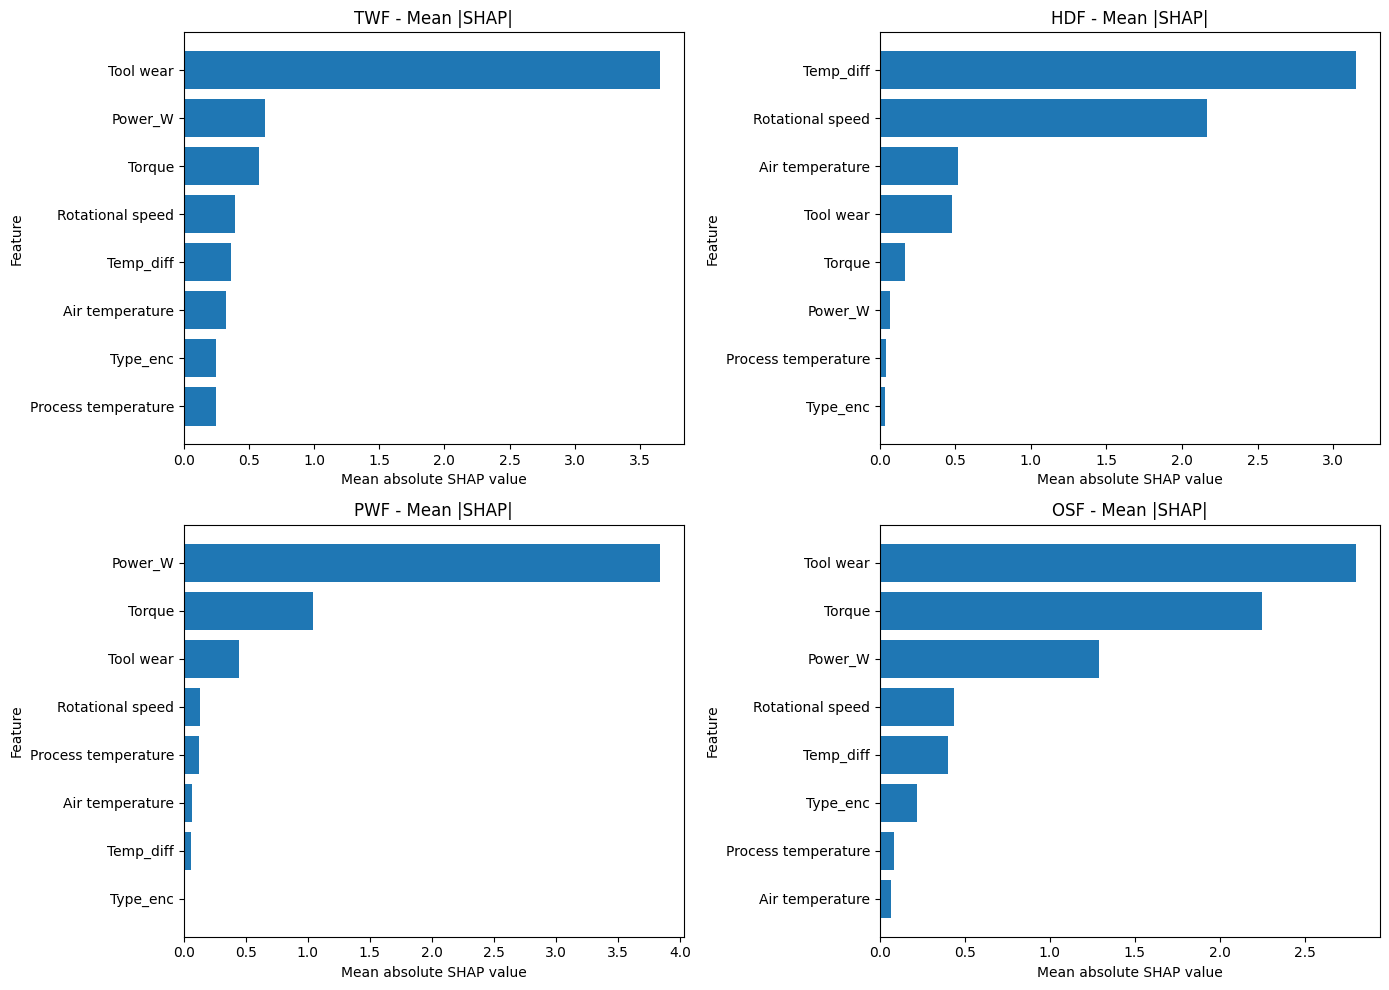

SHAP plot saved as shap_per_class.png
Top driver per failure class:


,failure_class,top_driver,mean_abs_shap
0,TWF,Tool wear,3.655387
1,HDF,Temp_diff,3.152347
2,PWF,Power_W,3.840327
3,OSF,Tool wear,2.802017


In [12]:
import shap

best_model = joblib.load('best_model.pkl')

# Use training features for SHAP
X_shap = train[FEATURES].copy()

# Compute SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# Convert SHAP output into shape: n_samples, n_features, n_classes
if isinstance(shap_values, list):
    # Older SHAP versions may return a list of arrays, one per class
    shap_array = np.stack(shap_values, axis=2)
else:
    shap_array = np.array(shap_values)

print("SHAP array shape:", shap_array.shape)

failure_classes = {
    1: "TWF",
    2: "HDF",
    3: "PWF",
    4: "OSF"
}

feature_names = X_shap.columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

top_drivers = {}

for ax, (class_id, class_name) in zip(axes, failure_classes.items()):

    # Mean absolute SHAP for this class
    class_shap = shap_array[:, :, class_id]
    mean_abs_shap = np.abs(class_shap).mean(axis=0)

    shap_importance = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=True)

    # Store top driver
    top_feature = shap_importance.iloc[-1]["feature"]
    top_score = shap_importance.iloc[-1]["mean_abs_shap"]

    top_drivers[class_name] = {
        "top_feature": top_feature,
        "mean_abs_shap": top_score
    }

    # Plot horizontal bar chart
    ax.barh(
        shap_importance["feature"],
        shap_importance["mean_abs_shap"]
    )

    ax.set_title(f"{class_name} - Mean |SHAP|")
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig("shap_per_class.png", dpi=300, bbox_inches="tight")
plt.show()

print("SHAP plot saved as shap_per_class.png")

top_driver_df = pd.DataFrame(top_drivers).T.reset_index()
top_driver_df.columns = ["failure_class", "top_driver", "mean_abs_shap"]

print("Top driver per failure class:")
display(top_driver_df.round(4))

### 4.2 Engineering interpretation

Interpret the class-specific SHAP results in terms of physical machine behavior and maintenance risk.

1. Power_W for PWF: `Power_W` is the strongest SHAP driver for `PWF`, clearly ranking above both raw `Torque` and `Rotational speed`. This makes sense because `Power_W` combines torque and rotational speed into one mechanical load feature, making it more informative for power-related failure than either raw variable alone.

2. Temp_diff for HDF: `Temp_diff` is the top driver for `HDF`, but it is much less important for the other failure types. This indicates that heat dissipation failure is strongly linked to the gap between process temperature and air temperature, while failures like `TWF`, `PWF`, and `OSF` are driven more by wear, torque, and mechanical power.

3. Physical mechanisms: `TWF` is mainly driven by `Tool wear`, suggesting that accumulated usage and degradation of the tool increases the probability of tool wear failure. `HDF` is mainly driven by `Temp_diff`, meaning poor heat dissipation becomes likely when the machine’s process temperature rises relative to ambient air temperature. `PWF` is mainly driven by `Power_W`, showing that high mechanical power demand can overload the system, while `OSF` is driven by `Tool wear` and `Torque`, suggesting overstrain occurs when worn tools operate under high load.

## 5. Conclusions

### 5.1 Key findings

Summarize the final model choice, metric rationale, rare-class limitation, drift findings, and one actionable engineering recommendation.

## Conclusions

**1. Model selection:**
In the initial model comparison, `XGBoost` won with the highest `macro_f1` of `0.7481`, outperforming `RandomForest` (`0.7355`), `LightGBM` (`0.7296`), and `LogisticRegression` (`0.5312`). After Optuna tuning, the final `XGBoost` model improved to a `macro_f1` of `0.7610`, giving an improvement of `+0.0129` over the baseline XGBoost. Therefore, tuned `XGBoost` was selected as the final model.

**2. Accuracy vs Macro F1:**
Accuracy is misleading here because the dataset is dominated by the `No Failure` class, so a model can get high accuracy by mostly predicting the majority class. `macro_f1` is more reliable because it evaluates performance across all classes equally, including rare but operationally important failures such as `TWF`, `HDF`, `PWF`, and `OSF`.

**3. The TWF problem:**
The low `TWF` performance is primarily a data engineering limitation, not just a modelling issue, because `TWF` has only about `30` real samples. Even after SMOTE and Optuna tuning, synthetic oversampling cannot fully replace genuine examples of rare tool wear failure patterns, so the fix is to collect more labelled `TWF` cases from real machine operation, especially near high `Tool wear` conditions and confirmed tool degradation events.

**4. Drift and maintenance schedule:**
In the stable current batch, Evidently detected no drift, with `0` drifted features and a drift share of `0.0`. In the stress batch, `Rotational speed`, `Torque`, and `Tool wear` drifted, with `Tool wear` increasing strongly and `Torque` also increasing, which implies higher risk of wear-driven and load-driven failures. This suggests maintenance scheduling should prioritize tool inspection/replacement and overload monitoring during stress operating periods.

**5. Actionable recommendation:**
**Condition:** `Tool wear` increases sharply and `Torque` shifts upward under stress conditions  
**Risked failure class:** `OSF` and `TWF`, with possible `PWF` risk when high torque increases mechanical power  
**Action:** Schedule preventive tool inspection or replacement, monitor torque/load trends during heavy-load periods, and flag machines operating with both high `Tool wear` and high `Torque` for priority maintenance.